# XSR benchmark results

This notebook reads the published benchmark result folders and shows the
throughput, latency, and XSR/VSR comparisons used in the paper.


## 1. Settings


In [1]:
CREATE_ARTIFACTS = False
SATURATION_RESULT = "20260827T013338Z-157571"
FIXED_RATE_RESULT = "20260827T213312Z-28024"

PAPER_MAX_CONCURRENCY = 256
FIXED_RATE_CONCURRENCY = None
CENTRAL_STATISTIC = "mean"
ERROR_STATISTIC = "ci95"

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "benchmarks" / "routing_wrk").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the XSR repository.")

REPO_ROOT = repository_root(Path.cwd().resolve())
RESULTS_ROOT = REPO_ROOT / "results" / "routing-performance"
sys.path.insert(0, str(REPO_ROOT / "benchmarks" / "routing_wrk"))

from analysis_utils import (
    REQUIRED_SYSTEMS, flatten_summary, load_trial_records,
    paired_ratios, paper_valid_configurations,
)


## 2. Result folders


In [2]:
def open_result(run_id, mode):
    run_dir = RESULTS_ROOT / run_id
    summary_path = run_dir / "summary.json"
    if not summary_path.is_file():
        raise FileNotFoundError(f"Missing result file: {summary_path}")
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    found_modes = {row.get("mode") for row in summary.get("results", [])}
    if mode not in found_modes:
        raise ValueError(f"{run_id} does not contain {mode} results")
    return run_dir, summary

SATURATION_DIR, saturation_summary = open_result(SATURATION_RESULT, "saturation")
FIXED_RATE_DIR, fixed_rate_summary = open_result(FIXED_RATE_RESULT, "fixed-rate")
FIXED_RATE_RUN_LABEL = FIXED_RATE_DIR.name

print(f"Saturation: {SATURATION_DIR}")
print(f"Fixed rate: {FIXED_RATE_DIR}")


Saturation: /home/pkimchi/ebpf-router-test/tools/XDP/results/routing-performance/20260827T013338Z-157571
Fixed rate: /home/pkimchi/ebpf-router-test/tools/XDP/results/routing-performance/20260827T213312Z-28024


## 3. Load results


In [3]:
def load_result(run_dir, summary):
    aggregate_rows = flatten_summary(summary, run_dir.name)
    trial_rows = load_trial_records(run_dir, run_dir.name)
    if not aggregate_rows or not trial_rows:
        raise ValueError(f"No benchmark data found in {run_dir}")
    return pd.DataFrame(aggregate_rows), pd.DataFrame(trial_rows)

saturation_results, saturation_trials = load_result(SATURATION_DIR, saturation_summary)
fixed_rate_results, fixed_rate_trials = load_result(FIXED_RATE_DIR, fixed_rate_summary)

saturation_metadata = saturation_summary["metadata"]
fixed_rate_metadata = fixed_rate_summary["metadata"]

print(f"Loaded {len(saturation_trials)} saturation trials and {len(fixed_rate_trials)} fixed-rate trials.")


Loaded 237 saturation trials and 100 fixed-rate trials.


## 4. Prepare results


In [4]:
saturation_trial_count = int(saturation_metadata["benchmark"]["trial_count"])
paper_configurations = paper_valid_configurations(
    saturation_results.to_dict("records"),
    saturation_trial_count,
    paper_max_concurrency=PAPER_MAX_CONCURRENCY,
    required_metrics=("throughput_rps", "average_latency_us"),
)
paper_valid_results = saturation_results[
    saturation_results.configuration.isin(paper_configurations)
].copy()
paper_concurrencies = sorted(paper_valid_results.concurrency.unique())
if not paper_concurrencies:
    raise ValueError("No complete saturation results are available for the figures")

paired_trial_ratios = pd.DataFrame(paired_ratios(
    saturation_trials.to_dict("records"),
    "XSR (SK_SKB/SOCKMAP)",
    "VSR (Envoy ExtProc)",
    "throughput_rps",
    paper_configurations,
))
print("Request concurrencies:", ", ".join(str(int(value)) for value in paper_concurrencies))


Request concurrencies: 1, 2, 4, 8, 16, 32, 64, 96, 128, 192


## 5. Saturation throughput and latency


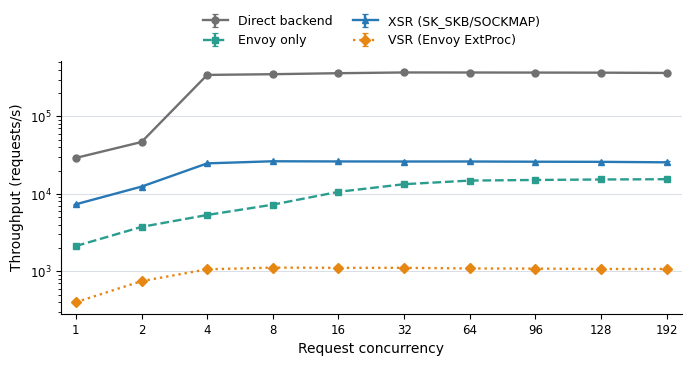

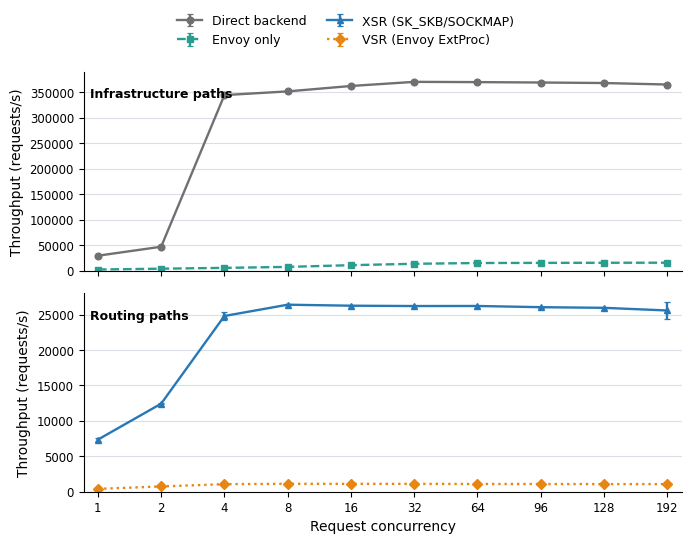

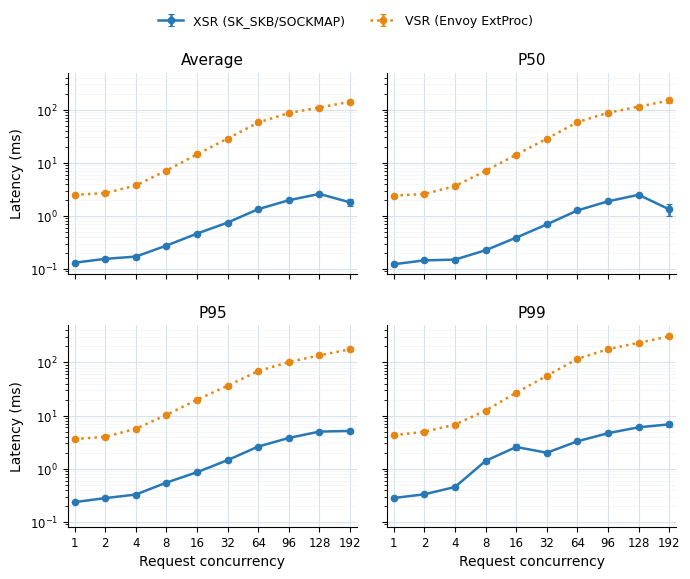

In [5]:
SYSTEM_STYLE = {
    "Direct backend": {"color": "#707070", "marker": "o", "linestyle": "-"},
    "Envoy only": {"color": "#2a9d8f", "marker": "s", "linestyle": "--"},
    "XSR (SK_SKB/SOCKMAP)": {"color": "#2878b5", "marker": "^", "linestyle": "-"},
    "VSR (Envoy ExtProc)": {"color": "#e68613", "marker": "D", "linestyle": ":"},
}
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.size": 9.5, "axes.labelsize": 10, "axes.titlesize": 11,
    "legend.fontsize": 9, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
OUTPUT_RUN_ID = f"{SATURATION_DIR.name}__{FIXED_RATE_RUN_LABEL}"
EXPORT_DIR = REPO_ROOT / "results" / "charts" / OUTPUT_RUN_ID
if CREATE_ARTIFACTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def export_figure(figure, stem):
    if CREATE_ARTIFACTS:
        figure.savefig(EXPORT_DIR / f"{stem}.pdf", bbox_inches="tight")
        figure.savefig(EXPORT_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)

saturation_throughput = paper_valid_results[paper_valid_results.metric.eq("throughput_rps")].copy()
throughput_ticks = sorted(saturation_throughput.concurrency.unique())
throughput_positions = np.arange(len(throughput_ticks))
SATURATION_THROUGHPUT_WIDTH = 7.0
fig, ax = plt.subplots(figsize=(SATURATION_THROUGHPUT_WIDTH, 3.75))
for system in REQUIRED_SYSTEMS:
    frame = saturation_throughput[saturation_throughput.system.eq(system)].sort_values("concurrency")
    style = SYSTEM_STYLE[system]
    positions = [throughput_ticks.index(value) for value in frame.concurrency]
    ax.errorbar(positions, frame[CENTRAL_STATISTIC], yerr=frame[ERROR_STATISTIC], label=system,
                color=style["color"], marker=style["marker"], linestyle=style["linestyle"],
                linewidth=1.7, markersize=5, capsize=2.5, capthick=0.9)
ax.set_xticks(throughput_positions, [str(value) for value in throughput_ticks])
ax.set_xlabel("Request concurrency"); ax.set_ylabel("Throughput (requests/s)")
ax.set_yscale("log")
ax.margins(x=0.025)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2, frameon=False, columnspacing=1.6)
ax.grid(False, axis="both", which="both")
ax.grid(axis="y", which="major", color="#d9dee7", linewidth=0.75)
ax.set_axisbelow(True); fig.tight_layout()
export_figure(fig, "saturation_throughput")
if CREATE_ARTIFACTS:
    saturation_throughput.to_csv(EXPORT_DIR / "plotted_saturation_data.csv", index=False)

facet_groups = [
    ("Infrastructure paths", ("Direct backend", "Envoy only")),
    ("Routing paths", ("XSR (SK_SKB/SOCKMAP)", "VSR (Envoy ExtProc)")),
]
SATURATION_THROUGHPUT_FACETED_WIDTH = 7.0
fig, axes = plt.subplots(2, 1, figsize=(SATURATION_THROUGHPUT_FACETED_WIDTH, 5.45), sharex=True)
for axis, (panel_label, panel_systems) in zip(axes, facet_groups):
    for system in panel_systems:
        frame = saturation_throughput[saturation_throughput.system.eq(system)].sort_values("concurrency")
        style = SYSTEM_STYLE[system]
        positions = [throughput_ticks.index(value) for value in frame.concurrency]
        lower_error = np.minimum(frame[ERROR_STATISTIC].to_numpy(), frame[CENTRAL_STATISTIC].to_numpy())
        upper_error = frame[ERROR_STATISTIC].to_numpy()
        axis.errorbar(positions, frame[CENTRAL_STATISTIC], yerr=np.vstack([lower_error, upper_error]), label=system,
                      color=style["color"], marker=style["marker"], linestyle=style["linestyle"],
                      linewidth=1.7, markersize=4.8, capsize=2.5, capthick=0.9)
    axis.set_ylim(bottom=0)
    axis.set_ylabel("Throughput (requests/s)")
    axis.text(0.01, 0.92, panel_label, transform=axis.transAxes, fontsize=9, weight="semibold", va="top")
    axis.grid(axis="y", color="#d9dee7", linewidth=0.8)
    axis.set_axisbelow(True); axis.margins(x=0.025)
axes[1].set_xticks(throughput_positions, [str(value) for value in throughput_ticks])
axes[1].set_xlabel("Request concurrency")
facet_handles, facet_labels = [], []
for axis in axes:
    handles, labels = axis.get_legend_handles_labels()
    facet_handles.extend(handles); facet_labels.extend(labels)
fig.legend(facet_handles, facet_labels, loc="upper center", bbox_to_anchor=(0.5, 1.0),
           ncol=2, frameon=False, columnspacing=1.6)
fig.tight_layout(rect=(0, 0, 1, 0.90), h_pad=1.1)
export_figure(fig, "saturation_throughput_faceted")

saturation_latency = paper_valid_results[paper_valid_results.metric.isin(["average_latency_us", "p50_latency_us", "p95_latency_us", "p99_latency_us"])].copy()
latency_panels = [("Average", "average_latency_us"), ("P50", "p50_latency_us"), ("P95", "p95_latency_us"), ("P99", "p99_latency_us")]
emphasized_systems = ("XSR (SK_SKB/SOCKMAP)", "VSR (Envoy ExtProc)")
SATURATION_LATENCY_WIDTH = 7.0
fig, axes = plt.subplots(2, 2, figsize=(SATURATION_LATENCY_WIDTH, 5.8), sharex=True, sharey=True)
for axis, (panel_label, metric) in zip(axes.flat, latency_panels):
    for system in emphasized_systems:
        frame = saturation_latency[(saturation_latency.metric == metric) & (saturation_latency.system == system)].sort_values("concurrency")
        style = SYSTEM_STYLE[system]
        positions = [throughput_ticks.index(value) for value in frame.concurrency]
        axis.errorbar(positions, frame[CENTRAL_STATISTIC], yerr=frame[ERROR_STATISTIC], label=system,
                      color=style["color"], marker="o", linestyle=style["linestyle"],
                      linewidth=1.8, markersize=4.5, capsize=2.2, capthick=0.8)
    axis.set_title(panel_label, pad=6)
    axis.set_yscale("log")
    axis.grid(which="major", color="#d9e1ec", linewidth=0.8)
    axis.grid(which="minor", color="#eef2f6", linewidth=0.45)
    axis.set_axisbelow(True)
    axis.margins(x=0.025)
for axis in axes[:, 0]: axis.set_ylabel("Latency (ms)")
for axis in axes[1, :]:
    axis.set_xticks(throughput_positions, [str(value) for value in throughput_ticks], rotation=0)
    axis.set_xlabel("Request concurrency")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94), h_pad=2.0, w_pad=1.5)
export_figure(fig, "saturation_latency")
if CREATE_ARTIFACTS:
    saturation_latency[saturation_latency.system.isin(emphasized_systems)].to_csv(
        EXPORT_DIR / "plotted_saturation_latency_data.csv", index=False
    )


## 6. Fixed-rate latency


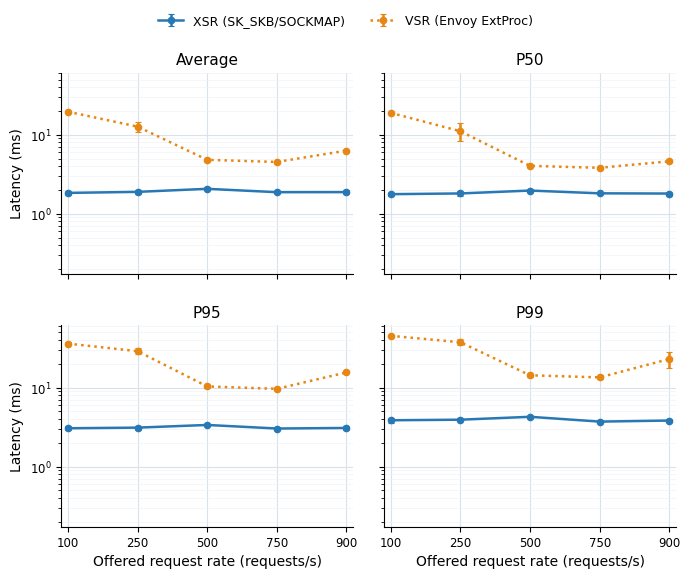

In [6]:
fixed_trial_count = int(fixed_rate_metadata["benchmark"]["trial_count"])
fixed_metrics = ("average_latency_us", "p50_latency_us", "p95_latency_us", "p99_latency_us")
fixed_valid_configurations = paper_valid_configurations(
    fixed_rate_results.to_dict("records"),
    fixed_trial_count,
    paper_max_concurrency=PAPER_MAX_CONCURRENCY,
    required_metrics=fixed_metrics,
)
available_concurrency = sorted(fixed_rate_results.concurrency.dropna().unique())
if FIXED_RATE_CONCURRENCY is None and len(available_concurrency) != 1:
    raise ValueError("Set FIXED_RATE_CONCURRENCY when the result folder contains more than one connection concurrency.")
selected_fixed_concurrency = FIXED_RATE_CONCURRENCY if FIXED_RATE_CONCURRENCY is not None else available_concurrency[0]
plotted_fixed_rate_data = fixed_rate_results[
    fixed_rate_results.configuration.isin(fixed_valid_configurations)
    & fixed_rate_results.concurrency.eq(selected_fixed_concurrency)
    & fixed_rate_results.metric.isin(["average_latency_us", "p50_latency_us", "p95_latency_us", "p99_latency_us"])
].copy()
fixed_rate_ticks = sorted(plotted_fixed_rate_data.offered_rate_rps.unique())
fixed_rate_positions = np.arange(len(fixed_rate_ticks))
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.8), sharex=True, sharey=True)
for axis, (label, metric) in zip(axes.flat, [("Average", "average_latency_us"), ("P50", "p50_latency_us"), ("P95", "p95_latency_us"), ("P99", "p99_latency_us")]):
    for system in emphasized_systems:
        frame = plotted_fixed_rate_data[(plotted_fixed_rate_data.metric == metric) & (plotted_fixed_rate_data.system == system)].sort_values("offered_rate_rps")
        style = SYSTEM_STYLE[system]
        positions = [fixed_rate_ticks.index(value) for value in frame.offered_rate_rps]
        axis.errorbar(positions, frame[CENTRAL_STATISTIC], yerr=frame[ERROR_STATISTIC], label=system,
                      color=style["color"], marker="o", linestyle=style["linestyle"],
                      linewidth=1.8, markersize=4.5, capsize=2.2, capthick=0.8)
    axis.set_title(label, pad=6); axis.set_yscale("log")
    axis.grid(which="major", color="#d9e1ec", linewidth=0.8)
    axis.grid(which="minor", color="#eef2f6", linewidth=0.45)
    axis.set_axisbelow(True); axis.margins(x=0.025)
for axis in axes[:, 0]: axis.set_ylabel("Latency (ms)")
for axis in axes[1, :]:
    axis.set_xticks(fixed_rate_positions, [str(value) for value in fixed_rate_ticks])
    axis.set_xlabel("Offered request rate (requests/s)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94), h_pad=2.0, w_pad=1.5)
export_figure(fig, "fixed_rate_latency")
if CREATE_ARTIFACTS:
    plotted_fixed_rate_data.to_csv(EXPORT_DIR / "plotted_fixed_rate_data.csv", index=False)


## 7. XSR and VSR comparison


In [7]:
if paired_trial_ratios.empty:
    raise ValueError("No paired XSR/VSR throughput trials are available")

xsr_vsr_speedup_by_concurrency = (
    paired_trial_ratios
    .groupby("concurrency", as_index=False)
    .agg(
        paired_trial_count=("ratio", "size"),
        mean_speedup=("ratio", "mean"),
        median_speedup=("ratio", "median"),
        minimum_speedup=("ratio", "min"),
        maximum_speedup=("ratio", "max"),
    )
    .sort_values("concurrency")
    .reset_index(drop=True)
)
print("XSR / VSR throughput speedup by request concurrency")
display(xsr_vsr_speedup_by_concurrency.style.format({
    "mean_speedup": "{:.2f}×",
    "median_speedup": "{:.2f}×",
    "minimum_speedup": "{:.2f}×",
    "maximum_speedup": "{:.2f}×",
}))

fixed_rate_latency = pd.DataFrame(paired_ratios(
    fixed_rate_trials.to_dict("records"),
    "VSR (Envoy ExtProc)",
    "XSR (SK_SKB/SOCKMAP)",
    "average_latency_us",
    fixed_valid_configurations,
))
fixed_rate_latency_by_trial = (
    fixed_rate_latency
    .pivot(index="offered_rate_rps", columns="trial", values="ratio")
    .sort_index()
)
fixed_rate_latency_by_trial.columns = [
    f"trial {int(trial)}" for trial in fixed_rate_latency_by_trial.columns
]
fixed_rate_latency_by_trial["mean"] = fixed_rate_latency_by_trial.mean(axis=1)
fixed_rate_latency_by_trial = fixed_rate_latency_by_trial.reset_index()
print("VSR / XSR average-latency difference by offered rate and trial")
display(fixed_rate_latency_by_trial.style.format({
    column: "{:.2f}×" for column in fixed_rate_latency_by_trial.columns
    if column != "offered_rate_rps"
}, na_rep="—"))

if CREATE_ARTIFACTS:
    xsr_vsr_speedup_by_concurrency.to_csv(EXPORT_DIR / "xsr_vsr_throughput_speedup.csv", index=False)
    fixed_rate_latency_by_trial.to_csv(EXPORT_DIR / "xsr_vsr_fixed_rate_latency.csv", index=False)
    print(f"Saved chart files to {EXPORT_DIR}")


XSR / VSR throughput speedup by request concurrency


,concurrency,paired_trial_count,mean_speedup,median_speedup,minimum_speedup,maximum_speedup
0,1,5,18.38×,18.51×,17.74×,18.94×
1,2,5,16.62×,16.49×,16.43×,17.15×
2,4,5,23.33×,23.35×,22.55×,23.85×
3,8,5,23.60×,23.57×,23.38×,23.80×
4,16,5,23.63×,23.60×,23.40×,24.02×
5,32,5,23.58×,23.58×,23.50×,23.70×
6,64,5,24.04×,24.01×,23.96×,24.13×
7,96,5,24.01×,23.96×,23.95×,24.13×
8,128,5,24.19×,24.13×,23.90×,24.74×
9,192,5,23.81×,24.31×,21.65×,24.43×


VSR / XSR average-latency difference by offered rate and trial


,offered_rate_rps,trial 1,trial 2,trial 3,trial 4,trial 5,mean
0,100,9.85×,10.34×,11.04×,10.67×,11.58×,10.70×
1,250,7.32×,7.79×,4.84×,6.77×,6.88×,6.72×
2,500,2.30×,2.31×,2.49×,2.34×,2.21×,2.33×
3,750,2.47×,2.40×,2.33×,2.41×,2.46×,2.42×
4,900,3.31×,3.42×,3.17×,3.47×,3.43×,3.36×
